In [7]:
# Import structural similarity index measure (SSIM) for image comparison
from skimage.metrics import structural_similarity as ssim
import numpy as np

# Load latitude and longitude data
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")

# Load model output arrays: saliency maps, evaluation gradients, and input gradients
sg = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/sg_zero_base.npy")  # Saliency maps
eg = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/eg_30_eval-1.npy")  # Evaluation gradients
ig = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/ig.npy")  # Input gradients

# Load input data and target variables
x = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]  # Extract soil moisture data

# Identify and remove samples with NaN values in the target variable
nanindex = np.where(np.isnan(y[:,205]))
x = np.delete(x, nanindex, axis=0)
y = np.delete(y, nanindex, axis=0)
y2 = np.delete(y2, nanindex, axis=0)
lats = np.delete(lats, nanindex, axis=0)
lons = np.delete(lons, nanindex, axis=0)

# Initialize array to store SSIM values for all samples, time steps, and comparison pairs
# Dimensions: [samples=733, time_steps=216, comparison_types=3]
ssim_np = np.full((733, 216, 3), np.nan)

# Loop through all samples and time steps to compute SSIM comparisons
for i in range(733):  # Loop through samples
    for j in range(216):  # Loop through time steps
        
        # Create land mask using NaN values from the 10th input variable (index 9)
        # This identifies land vs. non-land pixels
        mask_land = np.isnan(x[i, j, :, :, 9]) 
        
        # Apply land mask to gradient maps (set non-land areas to zero)
        ig_masked = ig[i, 0, j, :, :] * (1 - mask_land)  # Input gradients
        eg_masked = eg[i, 0, j, :, :] * (1 - mask_land)  # Evaluation gradients  
        sg_masked = sg[i, 0, j, :, :] * (1 - mask_land)  # Saliency gradients
        
        # Compute SSIM between different gradient map pairs:
        # SSIM measures structural similarity between images (range: -1 to 1, where 1 = identical)
        ssim_np[i, j, 0] = ssim(ig_masked, eg_masked, data_range=1)  # Input vs Evaluation gradients
        ssim_np[i, j, 1] = ssim(ig_masked, sg_masked, data_range=1)  # Input vs Saliency gradients
        ssim_np[i, j, 2] = ssim(eg_masked, sg_masked, data_range=1)  # Evaluation vs Saliency gradients

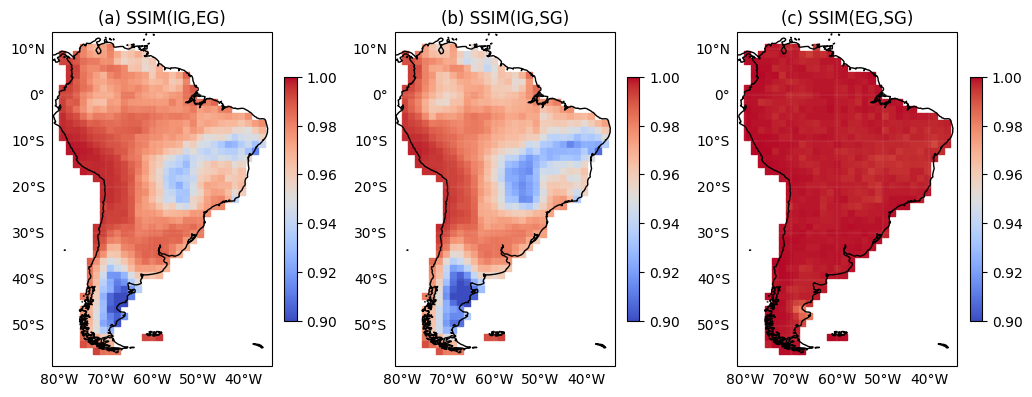

In [14]:
# Import necessary libraries for visualization and data handling
from matplotlib.colors import Normalize
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # For geographic projections
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
from get_lat_lon import get_lat_lon  # Custom module for coordinate handling
import numpy as np

# Create a 1x3 grid of subplots with geographic projection
fig, axis = plt.subplots(1, 3, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,6))

# Set color normalization range for SSIM values (0.9 to 1.0)
norm = Normalize(vmin=0.9, vmax=1)

# Titles for each subplot describing the SSIM comparison types
title_list = ["(a) SSIM(IG,EG)", "(b) SSIM(IG,SG)", "(c) SSIM(EG,SG)"]

# Loop through each subplot to create the three comparison maps
for i, ax in enumerate(axis.flat):
    # Add coastlines to the geographic map
    ax.coastlines()  # cartopy function
    
    # Configure gridlines with labels and styling
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
    gl.top_labels = False                                 
    gl.right_labels = False
    
    # Create scatter plot showing spatial distribution of mean SSIM values
    # np.mean(ssim_np[:,:,i],axis=1) calculates mean SSIM across time dimension for each location
    sc = ax.scatter(lons[:], lats[:], s=19, 
                   c=np.mean(ssim_np[:,:,i], axis=1),  # Mean SSIM across time
                   cmap='coolwarm', norm=norm, marker="s")
    
    # Add colorbar to each subplot for value interpretation
    plt.colorbar(sc, fraction=0.05)
    
    # Set title for each subplot
    ax.set_title(title_list[i])

# Adjust spacing between subplots for better layout
plt.subplots_adjust(wspace=0.4, hspace=0.1)